In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="5dQ43evdUvxGUmNDme7t")
project = rf.workspace("imit-h5ows").project("soil-detection-l0ngo")
version = project.version(3)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 89.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 92.4 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Soil-detection-3 in yolov8:: 100%|██████████| 582/582 [00:00<00:00, 6133.23it/s]


In [ ]:
import os

for root, dirs, files in os.walk("/content", topdown=True):
    print(root)

/content
/content/.config
/content/.config/logs
/content/.config/logs/2025.11.20
/content/.config/configurations
/content/Soil-detection-3
/content/Soil-detection-3/train
/content/Soil-detection-3/train/labels
/content/Soil-detection-3/train/images
/content/Soil-detection-3/test
/content/Soil-detection-3/test/labels
/content/Soil-detection-3/test/images
/content/Soil-detection-3/valid
/content/Soil-detection-3/valid/labels
/content/Soil-detection-3/valid/images
/content/sample_data


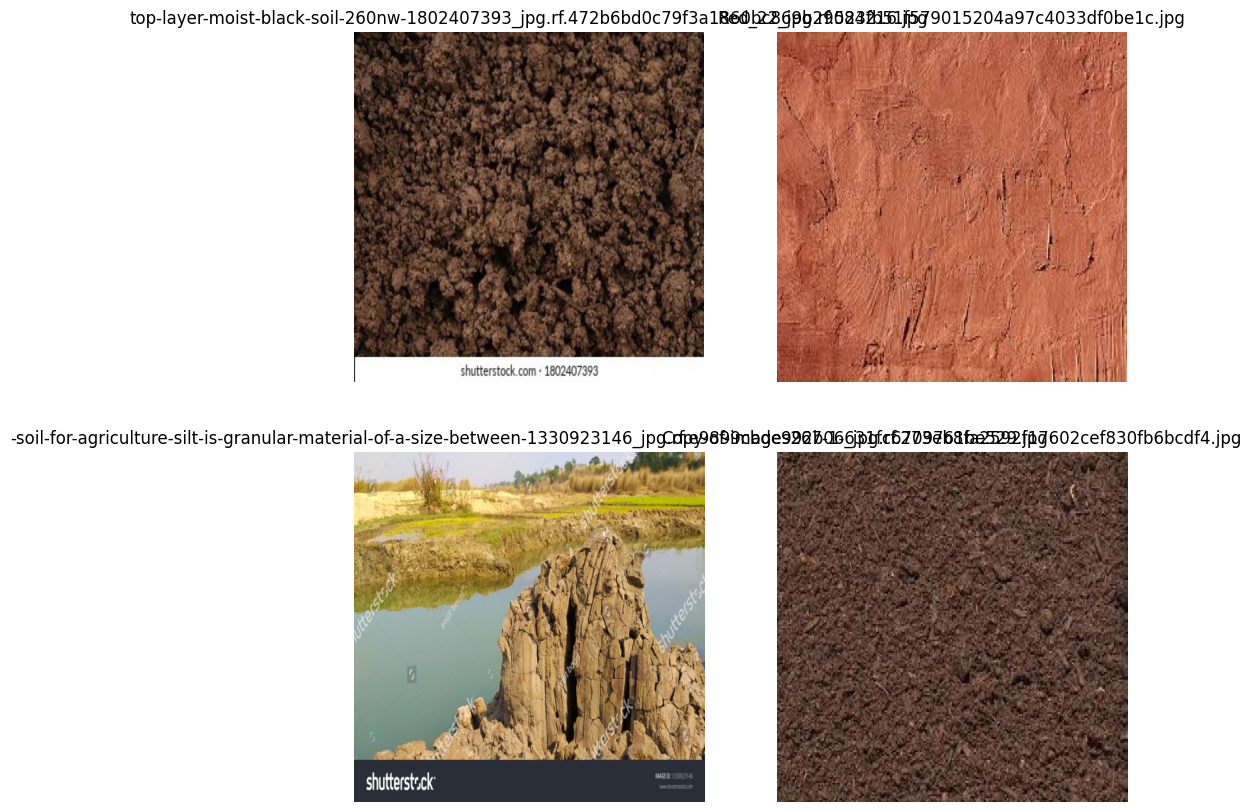

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

img_dir = "/content/Soil-detection-3/train/images"
images = os.listdir(img_dir)[:4]

plt.figure(figsize=(10,10))

for i, img_name in enumerate(images):
    img = cv2.imread(f"{img_dir}/{img_name}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(img_name)
    plt.axis('off')

plt.show()


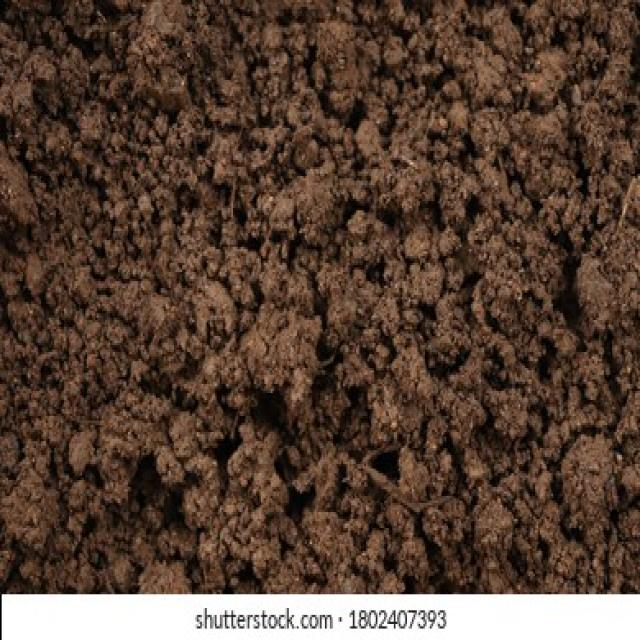

In [ ]:
import cv2
from google.colab.patches import cv2_imshow

img_path = "/content/Soil-detection-3/train/images"
first_image = os.listdir(img_path)[0]

img = cv2.imread(f"{img_path}/{first_image}")
cv2_imshow(img)


In [ ]:
#Data augmentation
import cv2
import albumentations as A
import os
import numpy as np

input_path = "/content/Soil-detection-3/train/images/"
output_path = "/content/augmented/images/"

# Create output folder
os.makedirs(output_path, exist_ok=True)

# Albumentations Transform
transform = A.Compose([
    A.Resize(640, 640),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomBrightnessContrast(p=0.4),
    A.Normalize(mean=(0,0,0), std=(1,1,1))   # keep image uint8-friendly
])

for img_name in os.listdir(input_path):

    input_img_path = os.path.join(input_path, img_name)

    img = cv2.imread(input_img_path)

    if img is None:
        print("Skipped:", img_name)
        continue

    # Apply transform
    transformed = transform(image=img)["image"]

    # Convert back to uint8 (important for saving)
    transformed = (transformed * 255).clip(0, 255).astype(np.uint8)

    # Save output image
    output_img_path = os.path.join(output_path, img_name)
    cv2.imwrite(output_img_path, transformed)

    print("Saved:", img_name)


FileNotFoundError: [Errno 2] No such file or directory: '/content/Soil-detection-3/train/images/'

In [ ]:
#Image scalling
import cv2
import os

input_path = "/content/Soil-detection-3/train/images/"
output_path = "/content/scaled_images/"

os.makedirs(output_path, exist_ok=True)

for img_name in os.listdir(input_path):
    img = cv2.imread(os.path.join(input_path, img_name))

    if img is None:
        print("Skipped:", img_name)
        continue

    # ---- SCALE IMAGE TO 640×640 ----
    scaled = cv2.resize(img, (640, 640), interpolation=cv2.INTER_LINEAR)

    cv2.imwrite(os.path.join(output_path, img_name), scaled)

print("Scaling completed!")


FileNotFoundError: [Errno 2] No such file or directory: '/content/Soil-detection-3/train/images/'

In [ ]:
#data cleaning
import cv2
import os
import shutil
import hashlib
import numpy as np

IMG_DIR = "/content/Soil-detection-3/train/images/"
LBL_DIR = "/content/Soil-detection-3/train/labels/"

CLEAN_IMG = "/content/clean_dataset/images/"
CLEAN_LBL = "/content/clean_dataset/labels/"

BAD_DIR = "/content/bad_images/"

os.makedirs(CLEAN_IMG, exist_ok=True)
os.makedirs(CLEAN_LBL, exist_ok=True)
os.makedirs(BAD_DIR, exist_ok=True)

# --- helper functions ---

def is_blurry(img, threshold=70):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    fm = cv2.Laplacian(gray, cv2.CV_64F).var()
    return fm < threshold


def image_hash(img):
    return hashlib.md5(img.tobytes()).hexdigest()


# --- main cleaning process ---

seen_hashes = set()

for img_name in os.listdir(IMG_DIR):

    img_path = os.path.join(IMG_DIR, img_name)
    base = os.path.splitext(img_name)[0]
    lbl_path = os.path.join(LBL_DIR, base + ".txt")

    # ---- 1. corrupted image check ----
    img = cv2.imread(img_path)
    if img is None:
        print("Corrupted:", img_name)
        shutil.move(img_path, BAD_DIR)
        continue

    # ---- 2. missing label check ----
    if not os.path.exists(lbl_path):
        print("Missing Label:", img_name)
        shutil.move(img_path, BAD_DIR)
        continue

    # ---- 3. resolution check ----
    h, w = img.shape[:2]
    if h < 256 or w < 256:
        print("Small Image Removed:", img_name)
        shutil.move(img_path, BAD_DIR)
        shutil.move(lbl_path, BAD_DIR)
        continue

    # ---- 4. blur check ----
    if is_blurry(img):
        print("Blurry Image Removed:", img_name)
        shutil.move(img_path, BAD_DIR)
        shutil.move(lbl_path, BAD_DIR)
        continue

    # ---- 5. duplicate check ----
    hsh = image_hash(img)
    if hsh in seen_hashes:
        print("Duplicate Removed:", img_name)
        shutil.move(img_path, BAD_DIR)
        shutil.move(lbl_path, BAD_DIR)
        continue
    seen_hashes.add(hsh)

    # ---- PASS → save clean files ----
    shutil.copy(img_path, CLEAN_IMG)
    shutil.copy(lbl_path, CLEAN_LBL)
    print("Clean:", img_name)

print("\nData Cleaning Completed!")
print(f"Clean images saved in: {CLEAN_IMG}")
print(f"Bad images saved in: {BAD_DIR}")


Clean: top-layer-moist-black-soil-260nw-1802407393_jpg.rf.472b6bd0c79f3a1860bc869b29084216.jpg
Clean: Red_22_jpg.rf.523fb51f579015204a97c4033df0be1c.jpg
Clean: -soil-for-agriculture-silt-is-granular-material-of-a-size-between-1330923146_jpg.rf.e9899cbde992b06631fc6709761be529.jpg
Clean: Copy-of-images267-1-_jpg.rf.273eb8fa2592f17602cef830fb6bcdf4.jpg
Clean: echinochloa-barnyard-sprout-has-grown-260nw-1759820435_jpg.rf.3ed761fea6e9622dcd1a304bcf0ec160.jpg
Clean: black-land-plant-background-top-260nw-1932861188_jpg.rf.046048c247b5eb343bdbe2ca56dc6ff3.jpg
Clean: black-land-plant-background-top-260nw-1690801567_jpg.rf.dccd52e43bbc1fc90fbc7822a280643a.jpg
Clean: Red_31_jpg.rf.e5f0f5a053953e706261d26d593e6734.jpg
Clean: regular-alluvium-soil-structures-on-260nw-595009385_jpg.rf.917fef150560a4c3f104841fa40fb091.jpg
Clean: soil-upper-layer-earth-which-260nw-1857677119_jpg.rf.de09703c108c666c59357058bb7b0508.jpg
Clean: Copy-of-indian-soils-6_jpg.rf.6bac8bb3f61b4bd7859f847e8bef28fa.jpg
Clean: OI

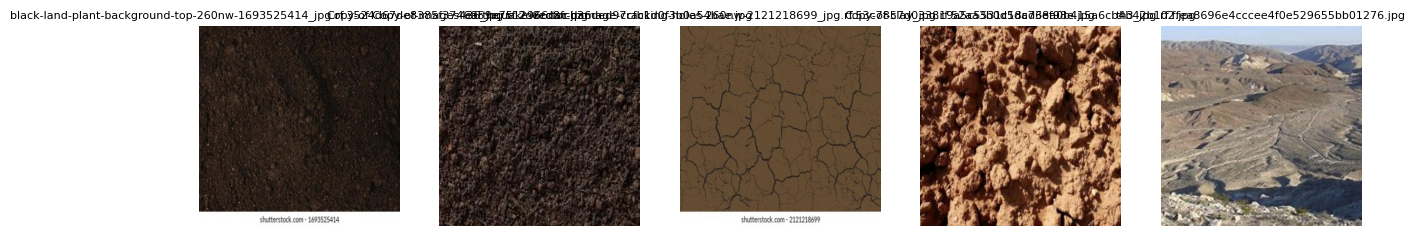

In [ ]:
#first 5 images
import os
import random
import matplotlib.pyplot as plt
import cv2

folder_path = "/content/Soil-detection-3/train/images/"

# Check if folder exists
if not os.path.exists(folder_path):
    print(" Folder not found:", folder_path)
else:
    # Get image files
    all_imgs = [f for f in os.listdir(folder_path)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Ensure at least 5 images exist
    if len(all_imgs) < 5:
        print(" Not enough images in folder. Found:", len(all_imgs))
    else:
        sample_imgs = random.sample(all_imgs, 5)

        plt.figure(figsize=(15, 5))

        for i, img_name in enumerate(sample_imgs):
            img_path = os.path.join(folder_path, img_name)
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(1, 5, i + 1)
            plt.imshow(img)
            plt.title(img_name, fontsize=8)
            plt.axis("off")

        plt.show()


In [ ]:
#dataset summary
import os
from pathlib import Path
from PIL import Image, ImageDraw, ImageFile
import numpy as np
import matplotlib.pyplot as plt
import random

ImageFile.LOAD_TRUNCATED_IMAGES = True

DATA_DIR = Path('/content/Soil-detection-3')  # adjust if different
SPLITS = ['train', 'valid', 'test']
print("==== DATASET SUMMARY ====\n")
total_images = total_labels = 0

for split in SPLITS:
    img_dir = DATA_DIR/split/'images'
    lbl_dir = DATA_DIR/split/'labels'
    imgs = sorted([p for p in img_dir.glob('*') if p.is_file()])
    lbls = sorted([p for p in lbl_dir.glob('*') if p.is_file()])
    print(f"{split.upper():5s} → images={len(imgs):3d}, labels={len(lbls):3d}")
    total_images += len(imgs)
    total_labels += len(lbls)

print(f"\nTOTAL IMAGES={total_images}, TOTAL LABELS={total_labels}")


==== DATASET SUMMARY ====

TRAIN → images=195, labels=197
VALID → images= 58, labels= 58
TEST  → images= 28, labels= 28

TOTAL IMAGES=281, TOTAL LABELS=283


In [ ]:
import os
from pathlib import Path
import numpy as np
from PIL import Image

# -------------------------------------
# 1. SET DATASET FOLDER to the cleaned images location
# -------------------------------------
CLEAN_DATA_DIR = Path("/content/clean_dataset")
IMG_SUBDIR = "images" # Subdirectory for images within the clean dataset

# -------------------------------------
# 2. CALCULATE MEAN & STD for the cleaned images
# -------------------------------------
img_dir_path = CLEAN_DATA_DIR / IMG_SUBDIR
imgs = list(img_dir_path.glob("*"))

if not imgs:
    print(f"No images found in {img_dir_path}. Cannot calculate mean and std.")
else:
    means, stds = [], []

    for p in imgs:
        try:
            img = np.array(Image.open(p).convert("RGB"), dtype=np.float32) / 255.0
        except Exception as e:
            print(f"Skipped unreadable file: {p} due to {e}")
            continue

        means.append(np.mean(img, axis=(0, 1)))
        stds.append(np.std(img, axis=(0, 1)))

    if means and stds:
        mean = np.mean(means, axis=0)
        std = np.mean(stds, axis=0)
        print(f"Mean (cleaned images): {mean}")
        print(f"Std (cleaned images): {std}")
    else:
        print("No valid images processed to calculate mean and std.")


TRAIN → mean=nan, std=nan
VALID → mean=nan, std=nan
TEST → mean=nan, std=nan


Mean of empty slice.
invalid value encountered in scalar divide


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import numpy as np

mask_dir = Path("/content/soil_dataset/train/masks")

for m in mask_dir.glob("*.png"):
    mask = np.array(Image.open(m))
    plt.imshow(mask, cmap="gray")
    plt.title(m.name)
    plt.axis("off")
    plt.show()

In [ ]:
import numpy as np
from pathlib import Path
from PIL import Image, ImageDraw

# --------------------------
# Path Setup
# --------------------------
DATA_DIR = Path("/content/soil_dataset")
SPLITS = ["train", "valid", "test"]

# --------------------------
# Function: YOLO TXT → Mask
# --------------------------
def yolo_txt_to_mask(img_path, txt_path):
    img = Image.open(img_path).convert("RGB")
    w, h = img.size

    # blank mask
    mask = Image.new("L", (w, h), 0)
    draw = ImageDraw.Draw(mask)

    # read txt
    if not txt_path.exists():
        return mask

    text = txt_path.read_text().strip()
    if not text:
        return mask

    # process each polygon
    for line in text.splitlines():
        parts = line.split()

        # YOLO format: class_id x1 y1 x2 y2 ... xn yn
        if len(parts) < 5:
            continue

        coords = list(map(float, parts[1:]))

        # must be even count (x,y pairs)
        if len(coords) % 2 != 0:
            continue

        # scale YOLO normalized coords to pixel coords
        pts = [(coords[i] * w, coords[i+1] * h) for i in range(0, len(coords), 2)]

        # draw polygon on mask
        if len(pts) >= 3:
            draw.polygon(pts, outline=255, fill=255)

    return mask

# --------------------------
# Create masks for all splits
# --------------------------
for split in SPLITS:
    img_dir = DATA_DIR / split / "images"
    lbl_dir = DATA_DIR / split / "labels"
    mask_dir = DATA_DIR / split / "masks"
    mask_dir.mkdir(parents=True, exist_ok=True)

    created = 0

    for img_path in img_dir.glob("*"):
        txt_path = lbl_dir / (img_path.stem + ".txt")
        mask_path = mask_dir / (img_path.stem + ".png")

        if txt_path.exists():
            mask = yolo_txt_to_mask(img_path, txt_path)
            mask.save(mask_path, "PNG")
            created += 1
        else:
            # create blank mask
            w, h = Image.open(img_path).size
            Image.new("L", (w, h), 0).save(mask_path)

    print(f"{split}: Created {created} masks")


train: Created 0 masks
valid: Created 0 masks
test: Created 0 masks


In [ ]:
#data modeling
import pandas as pd

data = {
    "image_path": ["img1.jpg", "img2.jpg"],
    "mask_path": ["img1.png", "img2.png"],
    "soil_type": ["black", "clay"],
    "pH": [6.5, 7.1],
    "moisture": [22.5, 18.9]
}

df = pd.DataFrame(data)
print(df)


  image_path mask_path soil_type   pH  moisture
0   img1.jpg  img1.png     black  6.5      22.5
1   img2.jpg  img2.png      clay  7.1      18.9


In [ ]:
import cv2
import os

folder = "/content/Soil-detection-3/train/images/"

def is_blurry(img, threshold=60):
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    fm = cv2.Laplacian(gray, cv2.CV_64F).var()
    return fm < threshold

for img_name in os.listdir(folder):
    img = cv2.imread(os.path.join(folder, img_name))
    if img is None: continue

    if is_blurry(img):
        print("Removed blurry:", img_name)
        os.remove(os.path.join(folder, img_name))
